# Temporal Analysis of FoB Surveys

In [792]:
import pandas as pd

In [793]:
questions = pd.read_csv('../../data/business_survey_msme/processed/questions_categorized.csv')
fob18 = pd.read_csv('../../data/business_survey_msme/processed/fob_18_dec_aggregated.csv')
fob19 = pd.read_csv('../../data/business_survey_msme/processed/fob_19_dec_aggregated.csv')
fob21 = pd.read_csv('../../data/business_survey_msme/processed/fob_21_sep_aggregated.csv')
fob19_spring = pd.read_csv('../../data/business_survey_msme/processed/fob_19_mar_aggregated.csv')
fob22 = pd.read_csv('../../data/business_survey_msme/processed/fob_22_mar_aggregated_demographic.csv')

In [794]:
fob18_gender = pd.read_csv('../../data/business_survey_msme/processed/fob_18_dec_aggregated_demographic.csv')
fob19_gender = pd.read_csv('../../data/business_survey_msme/processed/fob_19_dec_aggregated_demographic.csv')
fob21_gender = pd.read_csv('../../data/business_survey_msme/processed/fob_21_sep_aggregated_demographic.csv')
fob19_spring_gender = pd.read_csv('../../data/business_survey_msme/processed/fob_19_mar_aggregated_demographic.csv')
fob22_gender = pd.read_csv('../../data/business_survey_msme/processed/fob_22_mar_aggregated_demographic.csv')

In [795]:
fob22_gender = fob22_gender[fob22_gender['demographic_type']=='Gender']
fob21_gender = fob21_gender[fob21_gender['demographic_type']=='Gender']
fob19_spring_gender = fob19_spring_gender[fob19_spring_gender['demographic_type'] == 'dem_gen_text']
fob19_gender = fob19_gender[fob19_gender['demographic_type'] == 'sex_text']
fob18_gender = fob18_gender[fob18_gender['demographic_type']== 'fob_sex_text']

fob21_gender.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fob18_gender.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fob19_gender.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fob19_spring_gender.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fob18_gender.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [796]:

fob_gender_female_dfs = {
    'fob18': fob18_gender[fob18_gender['demographic_value'] == 'Female'],
    'fob19': fob19_gender[fob19_gender['demographic_value'] == 'Female'],
    'fob19_spring': fob19_spring_gender[fob19_spring_gender['demographic_value'] == 'Female'],
    'fob21': fob21_gender[fob21_gender['demographic_value'] == 'Female'],
    'fob22': fob22_gender[fob22_gender['demographic_value'] == 'Female']
}

fob_gender_male_dfs = {
    'fob18': fob18_gender[fob18_gender['demographic_value'] == 'Male'],
    'fob19': fob19_gender[fob19_gender['demographic_value'] == 'Male'],
    'fob19_spring': fob19_spring_gender[fob19_spring_gender['demographic_value'] == 'Male'],
    'fob21': fob21_gender[fob21_gender['demographic_value'] == 'Male'],
    'fob22': fob22_gender[fob22_gender['demographic_value'] == 'Male']
}

In [797]:
fob22 = fob22[fob22['demographic_type']=='Overall']


In [798]:
fob21.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fob18.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fob19.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fob19_spring.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fob22.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [799]:
questions.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [800]:
fob21['question'] = fob21['question'].apply(lambda x: x.replace('\n', ' '))
fob22['question'] = fob22['question'].apply(lambda x: x.replace('\n', ' '))

In [801]:
import ast
questions['question'] = questions['question'].apply(lambda x: ast.literal_eval(x))

In [802]:
def filter_fobs_by_questions(questions_list, fob_dfs):
    """
    Filter FOB dataframes based on a list of questions.
    
    Parameters:
    -----------
    questions_list : list or array-like
        List of question texts to filter for
    fob_dfs : dict
        Dictionary of FOB dataframes with descriptive keys
        Example: {'fob18': df1, 'fob19': df2, ...}
    
    Returns:
    --------
    dict
        Dictionary with same keys as input, containing filtered dataframes
    """
    filtered_dfs = {}
    
    for name, df in fob_dfs.items():
        # Filter to only include questions in the questions_list
        filtered_df = df[df['question'].isin(questions_list)].copy()
        
        if filtered_df.empty:
            # For each question in questions_list, extract meaningful words
            for q in questions_list:
                # Extract words longer than 3 characters
                words = [w for w in q.lower().split() if len(w) > 3]
                
                # Check if all words exist in each question in the FOB df
                mask = df['question'].apply(
                    lambda x: all(word in x.lower() for word in words)
                )
                filtered_df = pd.concat([filtered_df, df[mask]])
            
            filtered_df = filtered_df.drop_duplicates()
        
        filtered_dfs[name] = filtered_df
        
        #print(f"{name}: {len(filtered_df)} rows (from {len(df)} total) - {filtered_df['question'].nunique()} unique questions")
    
    return filtered_dfs

In [803]:
# Create dictionary of FOB dataframes
fob_dfs = {
    'fob18': fob18,
    'fob19_spring': fob19_spring,
    'fob19': fob19,
    'fob21': fob21,
    'fob22': fob22
}

In [804]:
import matplotlib.pyplot as plt
import math

def plot_surveys_grid(filtered_fobs_dict, main_title="Survey Comparison", subtitle="", source="", rows=2, figsize_per_plot=(6, 4)):
    """
    Create a grid of subplots with one subplot per survey dataframe.
    
    Parameters:
    -----------
    filtered_fobs_dict : dict
        Dictionary of filtered FOB dataframes (output from filter_fobs_by_questions)
        Example: {'fob18': df1, 'fob19': df2, ...}
    main_title : str
        Main title for the entire figure
    subtitle : str
        Subtitle for the entire figure
    source : str
        Source text to display at the bottom of the chart
    rows : int
        Number of rows in the subplot grid
    figsize_per_plot : tuple
        (width, height) for each individual subplot in inches
    
    Returns:
    --------
    matplotlib.figure.Figure
        Figure object with all subplots
    """
    # Define survey order and labels
    survey_order = ['fob18', 'fob19_spring', 'fob19', 'fob21', 'fob22']
    survey_labels = {
        'fob18': 'Dec 2018',
        'fob19_spring': 'Mar 2019',
        'fob19': 'Dec 2019',
        'fob21': 'Sep 2021',
        'fob22': 'Mar 2022'
    }
    
    # Filter out surveys with no data
    surveys_with_data = []
    for survey_key in survey_order:
        if survey_key in filtered_fobs_dict and len(filtered_fobs_dict[survey_key]) > 0:
            surveys_with_data.append(survey_key)
    
    n_surveys = len(surveys_with_data)
    
    if n_surveys == 0:
        print("No surveys with data to plot")
        return None
    
    # Calculate columns based on rows
    cols = math.ceil(n_surveys / rows)
    
    # Create figure with subplots and transparent background
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per_plot[0] * cols, figsize_per_plot[1] * rows))
    fig.patch.set_alpha(0.0)  # Make figure background transparent
    
    # Ensure axes is always a flat array
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # World Bank categorical color palette
    wb_colors = ['#0071BC', '#00A996', '#F05023', '#F78D28', '#009FDA', 
                 '#6C2C91', '#E31C3D', '#00AB51', '#FDB714', '#651D32']
    
    # Collect all unique responses across all surveys to create consistent color mapping
    all_responses = set()
    for survey_key in surveys_with_data:
        df = filtered_fobs_dict[survey_key]
        all_responses.update(df['response'].values)
    
    # Create a color mapping dictionary
    response_to_color = {response: wb_colors[i % len(wb_colors)] 
                        for i, response in enumerate(sorted(all_responses))}
    
    # Plot each survey
    for idx, survey_key in enumerate(surveys_with_data):
        ax = axes[idx]
        ax.patch.set_alpha(0.0)  # Make subplot background transparent
        
        df = filtered_fobs_dict[survey_key]
        
        # Get question text for title
        question_text = df['question'].iloc[0] if len(df) > 0 else "No Question"
        
        # Cut title after first question mark
        if '?' in question_text:
            question_text = question_text.split('?')[0] + '?'
        
        # Get max n value
        max_n = df['n'].max() if 'n' in df.columns and len(df) > 0 else 0
        
        # Get responses and values
        responses = df['response'].values
        values = df['value'].values
        
        # Create bar chart with consistent colors based on response text
        colors = [response_to_color[response] for response in responses]
        bars = ax.bar(range(len(responses)), values, color=colors)
        
        # Customize plot
        ax.set_xticks(range(len(responses)))
        ax.set_xticklabels(responses, rotation=45, ha='right', fontsize=9, fontfamily='Open Sans')
        ax.set_ylabel('Percentage (%)', fontsize=10, fontfamily='Open Sans')
        ax.set_ylim(0, 100)
        
        # Left-aligned title with question and survey label
        title_text = survey_labels[survey_key]
        ax.set_title(title_text, loc='left', fontsize=10, fontfamily='Open Sans', fontweight='bold', pad=20)
        
        # Add subtitle with n value below the title
        ax.text(0, 1.0, f'n = {max_n:,.0f}', transform=ax.transAxes, 
                fontsize=8, fontfamily='Open Sans', ha='left', va='bottom', color='#666666')
        
        # Remove grid and spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_color('#CCCCCC')
        ax.spines['left'].set_color('#CCCCCC')
        ax.tick_params(colors='#333333', which='both')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%',
                       ha='center', va='bottom', fontsize=8, fontfamily='Open Sans')
    
    # Hide unused subplots
    for idx in range(n_surveys, len(axes)):
        axes[idx].axis('off')
    
    # Add main title and subtitle with World Bank colors
    fig.text(0.02, 0.97, main_title, fontsize=14, fontfamily='Open Sans', 
             fontweight='bold', ha='left', va='top', transform=fig.transFigure, color='#002244')
    
    if subtitle:
        fig.text(0.02, 0.94, subtitle, fontsize=12, fontfamily='Open Sans', 
                 style='italic', ha='left', va='top', transform=fig.transFigure, color='#4D4D4D')
    
    # Add source at the bottom if provided
    if source:
        fig.text(0.02, 0.01, f'Source: {source}', fontsize=8, fontfamily='Open Sans', 
                 ha='left', va='bottom', transform=fig.transFigure, color='#666666')
        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    else:
        plt.tight_layout(rect=[0, 0, 1, 0.93])
    
    return fig

In [805]:
questions_in_all_5 = questions[questions['num_surveys'] == 5]['question'].iloc[0]



# Filter all dataframes
filtered_fobs = filter_fobs_by_questions(questions_in_all_5, fob_dfs)

# Access filtered dataframes
fob18_filtered = filtered_fobs['fob18']
fob19_spring_filtered = filtered_fobs['fob19_spring']
fob19_filtered = filtered_fobs['fob19']
fob21_filtered = filtered_fobs['fob21']
fob22_filtered = filtered_fobs['fob22']

### Size of Business

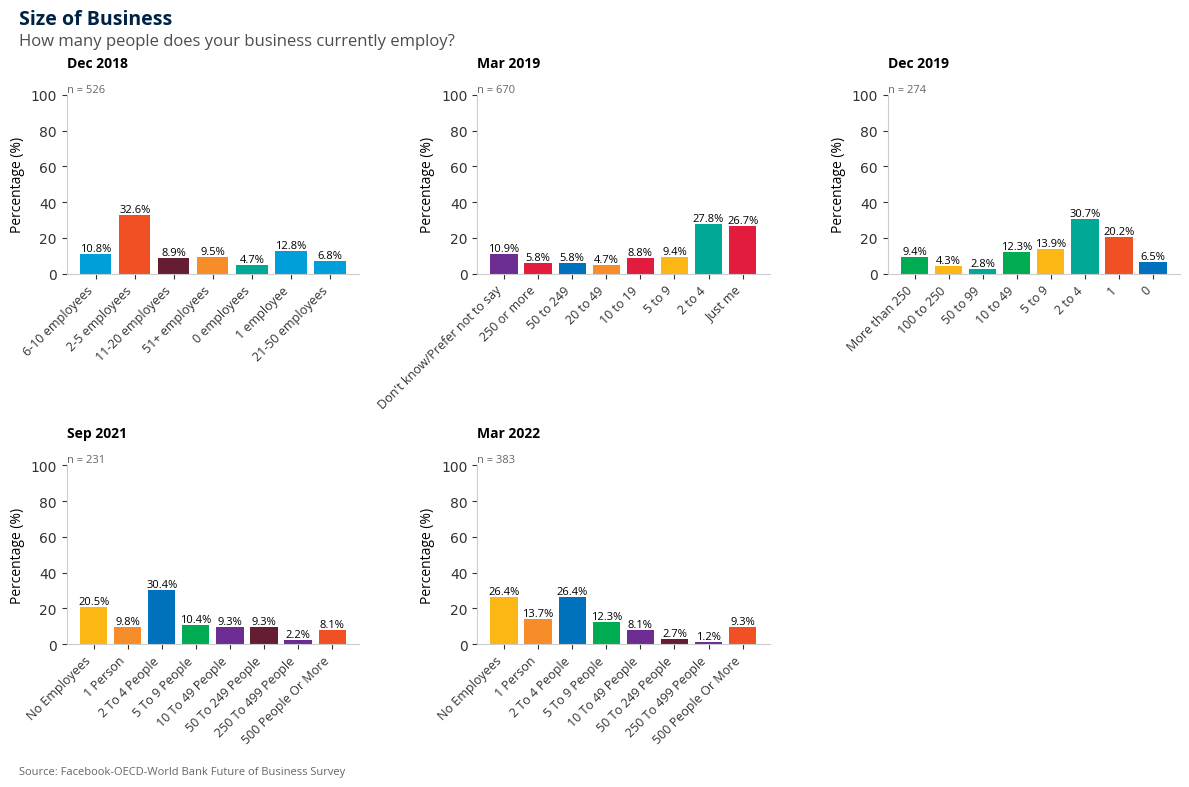

In [806]:
# Create grid with 2 rows
plot_surveys_grid(filtered_fobs, rows=2, figsize_per_plot=(4,4), 
                  main_title='Size of Business', 
                  subtitle='How many people does your business currently employ?',
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show()

**Insights**
- A siginificant portion (~30%) of the SME business owners are self employed and work alone or with one other person throughout the 5 years of survey period. 
- A small portion of business owners with slightly larger businesses seem to have become active on Facebook post COVID. 
- Businesses with very few employees (0-2) or slightly higher number (>250) retained their proportions in the survey. Whereas businesses with 10-50 employees reduced post COVID. 

### Line of Credit

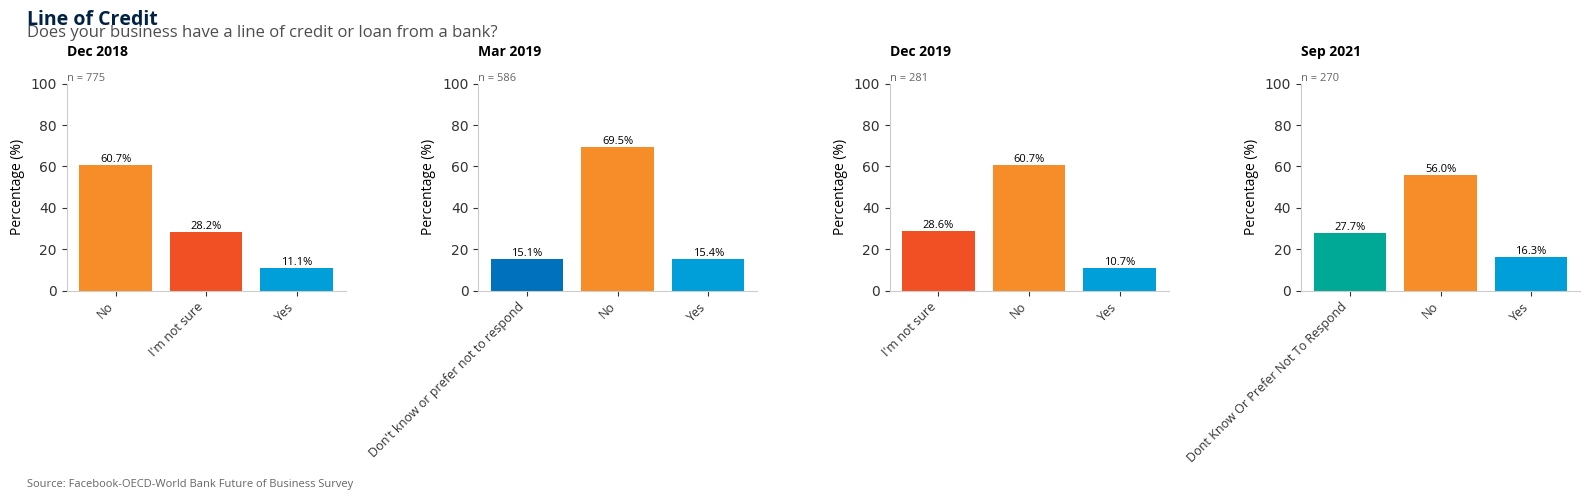

In [807]:
questions_in_all_4 = questions[questions['num_surveys'] == 4]['question'].iloc[4]

# Filter all dataframes
filtered_fobs = filter_fobs_by_questions(questions_in_all_4, fob_dfs)

# Access filtered dataframes
fob18_filtered = filtered_fobs['fob18']
fob19_spring_filtered = filtered_fobs['fob19_spring']
fob19_filtered = filtered_fobs['fob19']
fob21_filtered = filtered_fobs['fob21']
fob22_filtered = filtered_fobs['fob22']

# Create grid with 2 rows
plot_surveys_grid(filtered_fobs, rows=1, figsize_per_plot=(4,5), 
                  main_title='Line of Credit',
                  subtitle='Does your business have a line of credit or loan from a bank?',
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show()

**Insights**
- Most SMEs donot have a line of credit from a Bank. 
- A relatively consistent number of people have taken a line of credit. 
- There is an increase of people who reported to have taken a loan after COVID. 

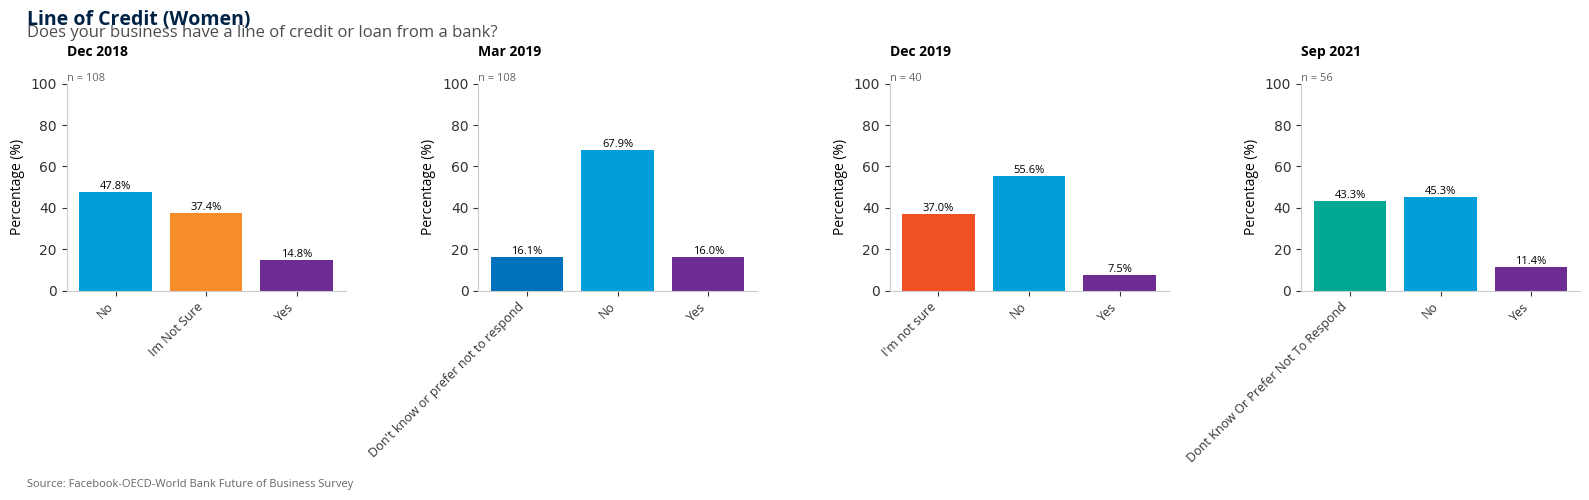

In [808]:
questions_in_all_4 = questions[questions['num_surveys'] == 4]['question'].iloc[4]

# Filter all dataframes
filtered_fobs = filter_fobs_by_questions(questions_in_all_4, fob_gender_female_dfs)

# Access filtered dataframes
fob18_filtered = filtered_fobs['fob18']
fob19_spring_filtered = filtered_fobs['fob19_spring']
fob19_filtered = filtered_fobs['fob19']
fob21_filtered = filtered_fobs['fob21']
fob22_filtered = filtered_fobs['fob22']

# Create grid with 2 rows
plot_surveys_grid(filtered_fobs, rows=1, figsize_per_plot=(4,5), 
                  main_title='Line of Credit (Women)',
                  subtitle='Does your business have a line of credit or loan from a bank?',
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show()

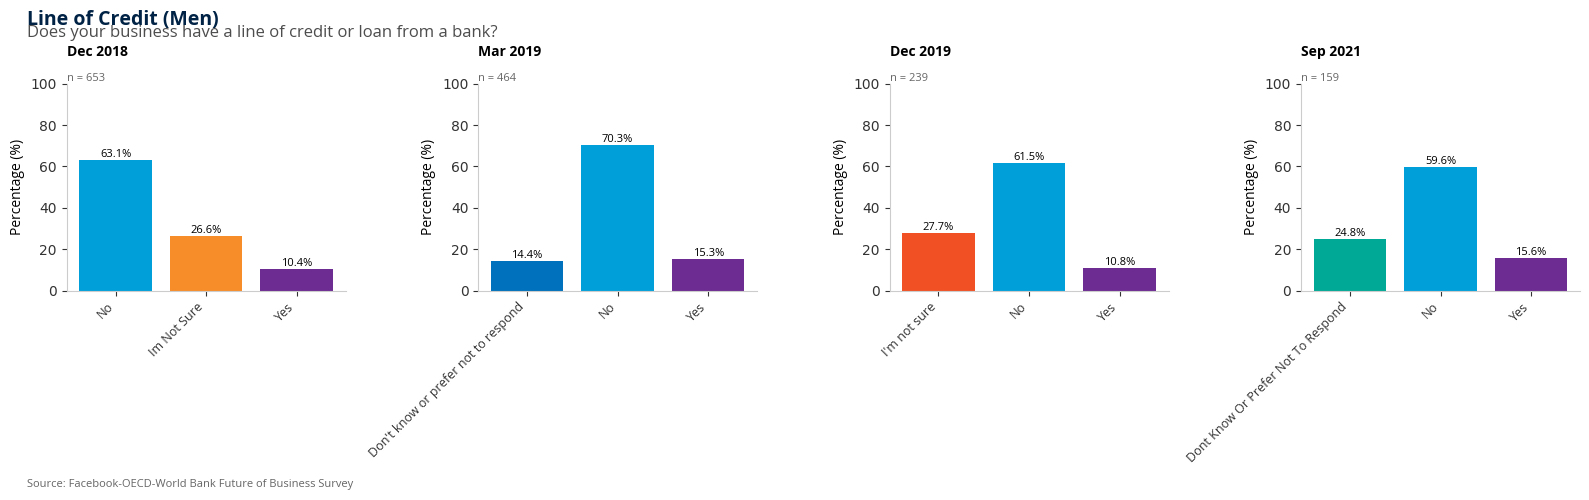

In [809]:
questions_in_all_4 = questions[questions['num_surveys'] == 4]['question'].iloc[4]

# Filter all dataframes
filtered_fobs = filter_fobs_by_questions(questions_in_all_4, fob_gender_male_dfs)

# Access filtered dataframes
fob18_filtered = filtered_fobs['fob18']
fob19_spring_filtered = filtered_fobs['fob19_spring']
fob19_filtered = filtered_fobs['fob19']
fob21_filtered = filtered_fobs['fob21']
fob22_filtered = filtered_fobs['fob22']

# Create grid with 2 rows
plot_surveys_grid(filtered_fobs, rows=1, figsize_per_plot=(4,5), 
                  main_title='Line of Credit (Men)',
                  subtitle='Does your business have a line of credit or loan from a bank?',
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show()

### COVID Support

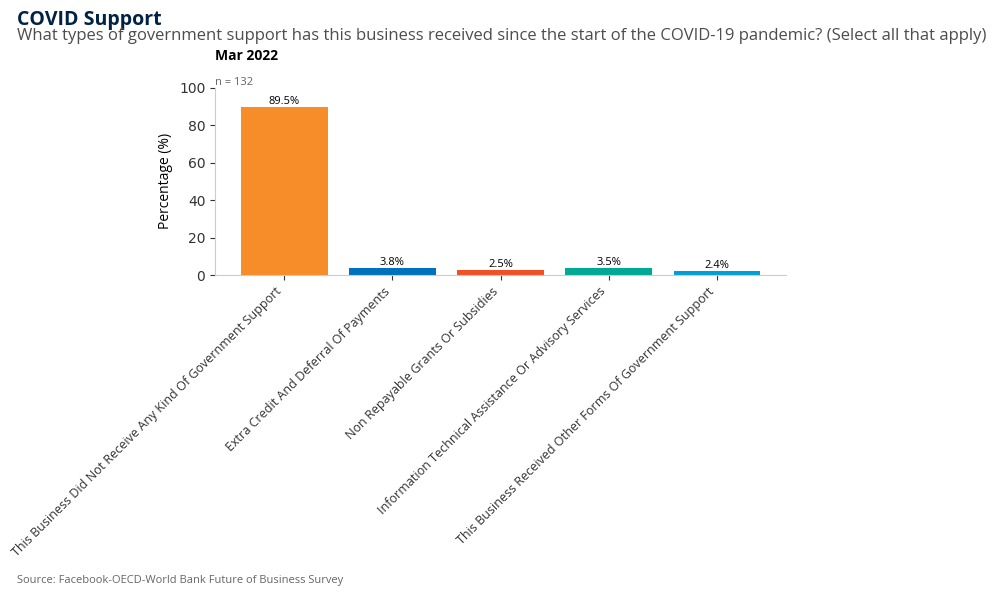

In [871]:
questions_covid = questions[questions['question_group']==93]['question'].iloc[0]

covid = filter_fobs_by_questions(questions_covid, fob_dfs)
#covid
covid22 = covid['fob22']
covid22.loc[covid22['response']=='Yes', 'response'] = covid22['question'].apply(lambda x: x.split('- ')[1])
covid22 = covid22[covid22['response']!='No']
covid22 = covid22[covid22['n']>0]

covid['fob22'] = covid22

plot_surveys_grid(covid, rows=1, figsize_per_plot=(8,6), 
                  main_title='COVID Support',
                  subtitle=questions[questions['question_group']==93]['question'].iloc[0][0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

**Insights**

- Only a small portion of people reported having support from the goverment after COVID.

### Motivation for Business

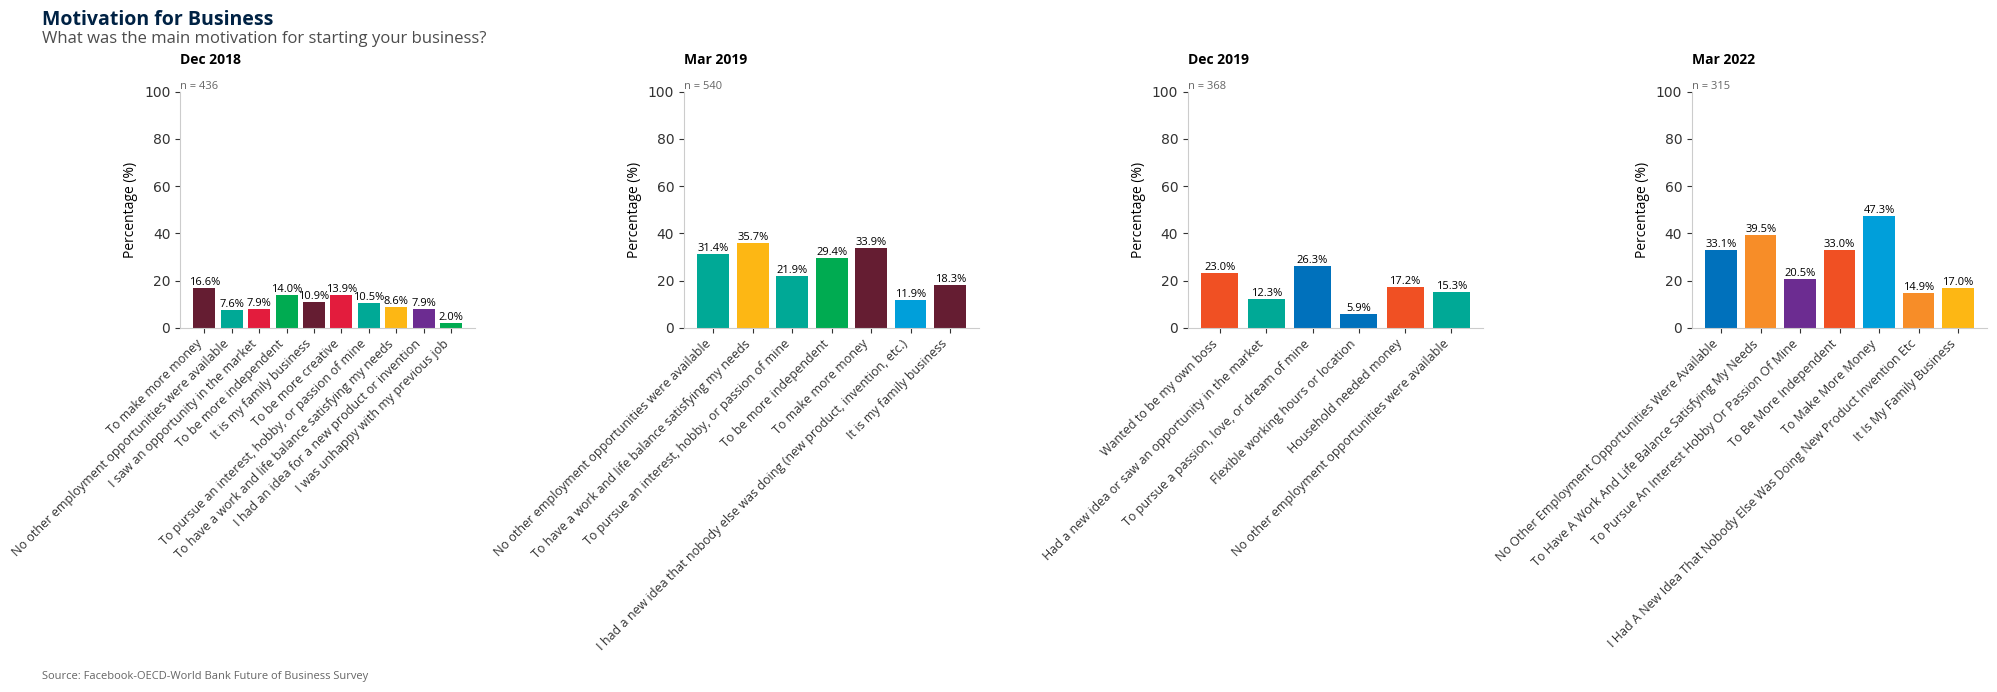

In [811]:
questions_in_all_4 = questions[questions['num_surveys'] == 4]['question'].iloc[3]

# Filter all dataframes
motivation_for_business = filter_fobs_by_questions(questions_in_all_4, fob_dfs)

fob19_filtered = motivation_for_business['fob19'].copy()
fob19_filtered = fob19_filtered[fob19_filtered['response']!=0.0]

fob19_spring_filtered = motivation_for_business['fob19_spring'].copy()
fob19_spring_filtered = fob19_spring_filtered[fob19_spring_filtered['response']!='0.0']

fob22_mob = motivation_for_business['fob22'].copy()
fob22_mob.loc[fob22_mob['response']=='Yes', 'response'] = fob22_mob['question'].apply(lambda x: x.split('- ')[1])
fob22_mob = fob22_mob[fob22_mob['response']!='No']
fob22_mob = fob22_mob[fob22_mob['n']>0]

motivation_for_business['fob19'] = fob19_filtered
motivation_for_business['fob19_spring'] = fob19_spring_filtered
motivation_for_business['fob22'] = fob22_mob

# Create grid with 2 rows
plot_surveys_grid(motivation_for_business, rows=1, figsize_per_plot=(5,7), 
                  main_title='Motivation for Business',
                  subtitle='What was the main motivation for starting your business?',
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

**Insights**
>The question was posed differently across the years where in 2019 March and 2022 they were asked to identify upto 3 reasons for motvation.

- 15% of the people have reported choosing this line of work because of no other forms of employment available. This remains consistent before and after COVID. 
- A significant portiobn of people reported choosing this to increase theior work life balance. 
- Number of people reporting wanting more income increased. 
> Did the inflation go up in this time?
- People consistently reported moving to market because they had an innovative idea
> Is the Ease of Doing Business Index high in Algeria?

### Challenges for Business

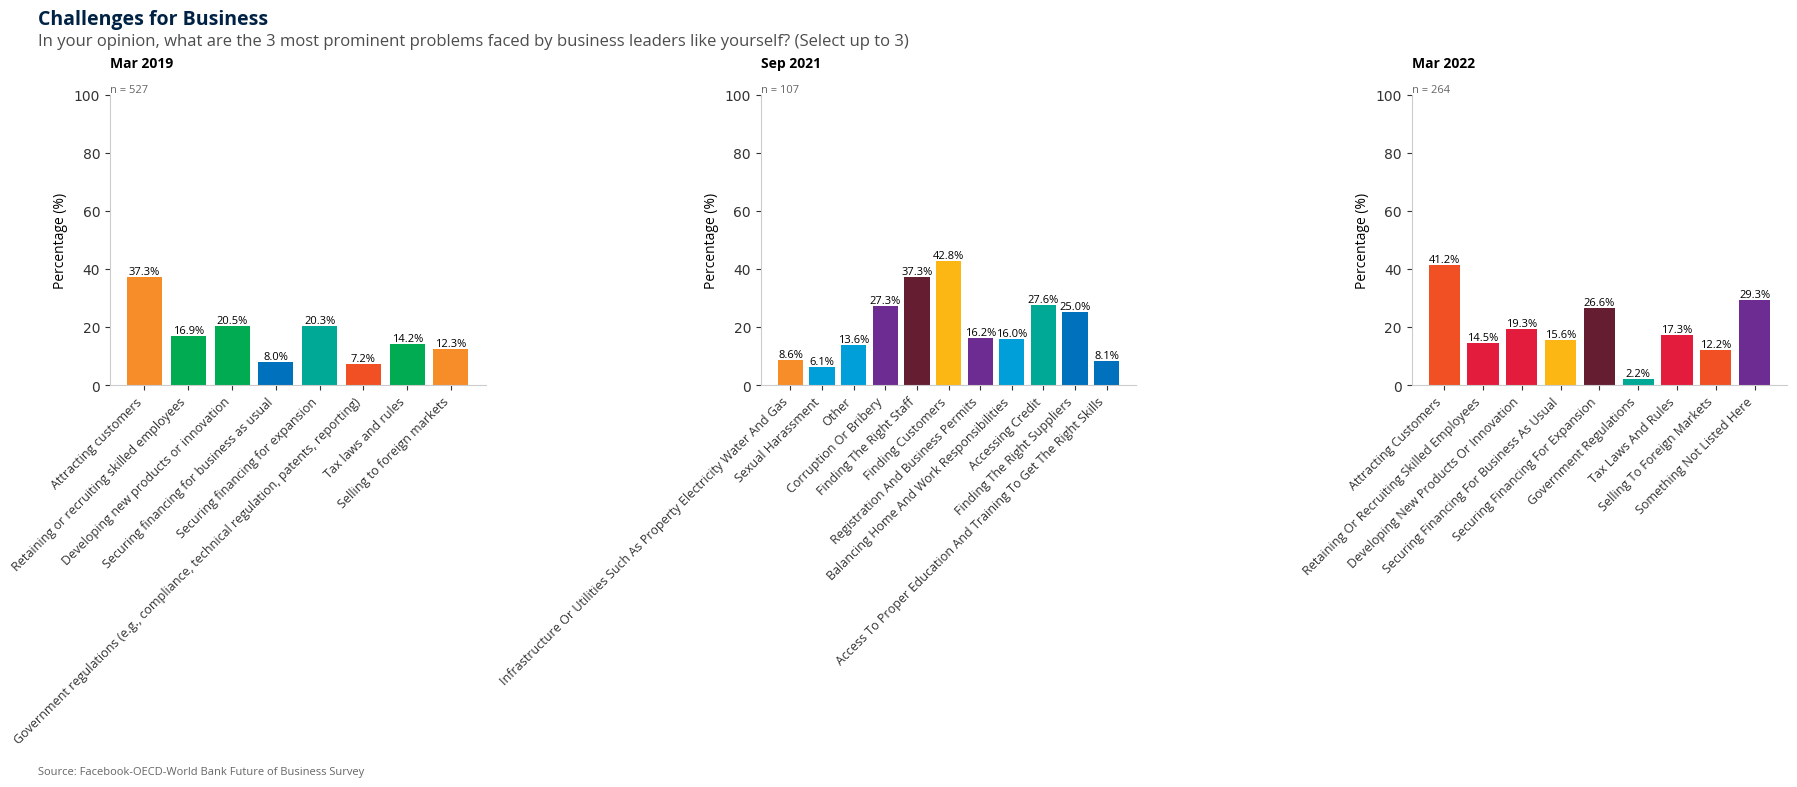

In [812]:
question_chl = questions[questions['num_surveys'] == 3]['question'].iloc[2]

# Filter all dataframes
challenges_for_business = filter_fobs_by_questions(question_chl, fob_dfs)

fob19_spring_chl = challenges_for_business['fob19_spring']
fob19_spring_chl = fob19_spring_chl[~fob19_spring_chl['variable'].isin(['bus_chl_translation', 'bus_chl_numeric_other_please_specify'])]
fob19_spring_chl = fob19_spring_chl[fob19_spring_chl['response']!='0.0']

fob21_chl = challenges_for_business['fob21'].copy()
fob21_chl.loc[fob21_chl['response']=='Yes', 'response'] = fob21_chl['question'].apply(lambda x: x.split('- ')[1])
fob21_chl = fob21_chl[fob21_chl['response']!='No']
fob21_chl = fob21_chl[fob21_chl['n']>0]

fob22_chl = challenges_for_business['fob22'].copy()
fob22_chl.loc[fob22_chl['response']=='Yes', 'response'] = fob22_chl['question'].apply(lambda x: x.split('- ')[1])
fob22_chl = fob22_chl[fob22_chl['response']!='No']
fob22_chl = fob22_chl[fob22_chl['n']>0]

challenges_for_business['fob19_spring'] = fob19_spring_chl
challenges_for_business['fob21'] = fob21_chl
challenges_for_business['fob22'] = fob22_chl

# Create grid with 2 rows
plot_surveys_grid(challenges_for_business, rows=1, figsize_per_plot=(6,8), 
                  main_title='Challenges for Business',
                  subtitle=question_chl[0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

**Insights**
- Attracting Customers is the biggest reported challenges across the years
> Sexual Harrassment was not explicitly mentioned in the other surveys

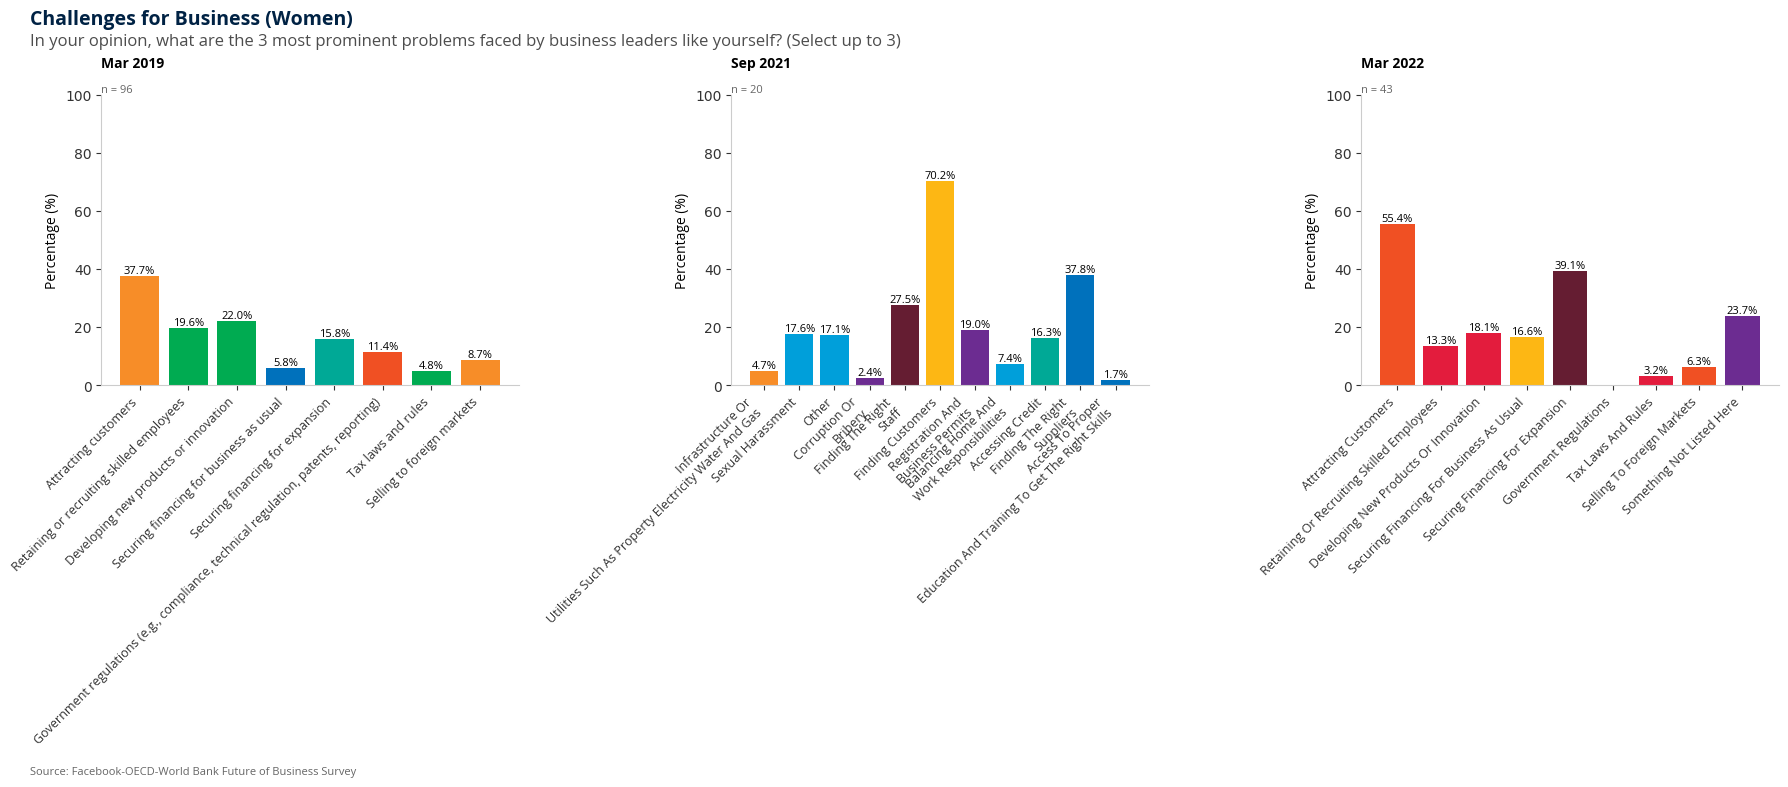

In [813]:
question_chl = questions[questions['num_surveys'] == 3]['question'].iloc[2]

# Filter all dataframes
challenges_for_business = filter_fobs_by_questions(question_chl, fob_gender_female_dfs)

fob19_spring_chl = challenges_for_business['fob19_spring']
fob19_spring_chl = fob19_spring_chl[~fob19_spring_chl['variable'].isin(['bus_chl_translation', 'bus_chl_numeric_other_please_specify'])]
fob19_spring_chl = fob19_spring_chl[fob19_spring_chl['response']!='0.0']

fob21_chl = challenges_for_business['fob21'].copy()
fob21_chl.loc[fob21_chl['response']=='Yes', 'response'] = fob21_chl['question'].apply(lambda x: x.split('- ')[1])
fob21_chl = fob21_chl[fob21_chl['response']!='No']
fob21_chl = fob21_chl[fob21_chl['n']>0]

fob22_chl = challenges_for_business['fob22'].copy()
fob22_chl.loc[fob22_chl['response']=='Yes', 'response'] = fob22_chl['question'].apply(lambda x: x.split('- ')[1])
fob22_chl = fob22_chl[fob22_chl['response']!='No']
fob22_chl = fob22_chl[fob22_chl['n']>0]



challenges_for_business['fob19_spring'] = fob19_spring_chl
challenges_for_business['fob21'] = fob21_chl
challenges_for_business['fob22'] = fob22_chl

# Create grid with 2 rows
plot_surveys_grid(challenges_for_business, rows=1, figsize_per_plot=(6,8), 
                  main_title='Challenges for Business (Women)',
                  subtitle=question_chl[0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

In [814]:
questions[questions['question'].apply(lambda q_list: any('profit' in q.lower() for q in q_list))]['question'].iloc[0]

['To the best of your knowledge, In a typical month, what are the profits to the owner(s) of this business (in {currency_symbol})?  Please enter only a single number',
 'To the best of your knowledge, in a typical month, what are the current profits to the owners of this business (in {currency_symbol})?',
 'To the best of your knowledge, in a typical month, what are the profits to the owner(s) of this business (in R)?']

In [815]:
questions[questions['question'].apply(lambda q_list: any('digital pla' in q.lower() for q in q_list))]['question'].iloc[0]

['What are the main challenges this business faces when using or trying to adopt digital platforms for the sale or purchase of goods and services? (Please select up to two)',
 'What are the main challenges this business might face if it tried to adopt digital platforms for the sale or purchase of goods and services? (Please select up to two)',
 'Which of the following describes this business’s use of digital platforms (online platforms to facilitate interactions with other firms, individuals, or the government)? (Select all that apply)']

### Training

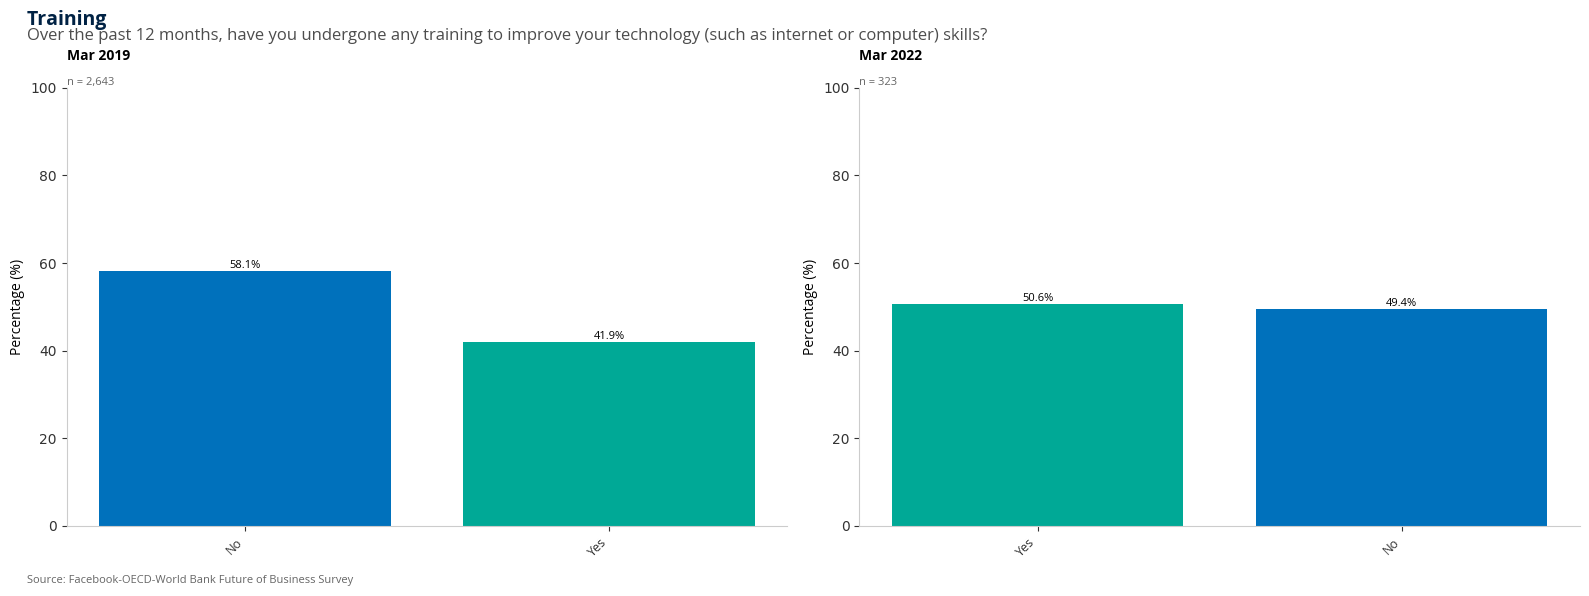

In [840]:
questions_in_all_4 = questions[questions['question_group'] == 57]['question'].iloc[0]

# Filter all dataframes
training = filter_fobs_by_questions(questions_in_all_4, fob_dfs)


# Create grid with 2 rows
plot_surveys_grid(training, rows=1, figsize_per_plot=(8,6), 
                  main_title='Training',
                  subtitle=questions[questions['question_group'] == 57]['question'].iloc[0][0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

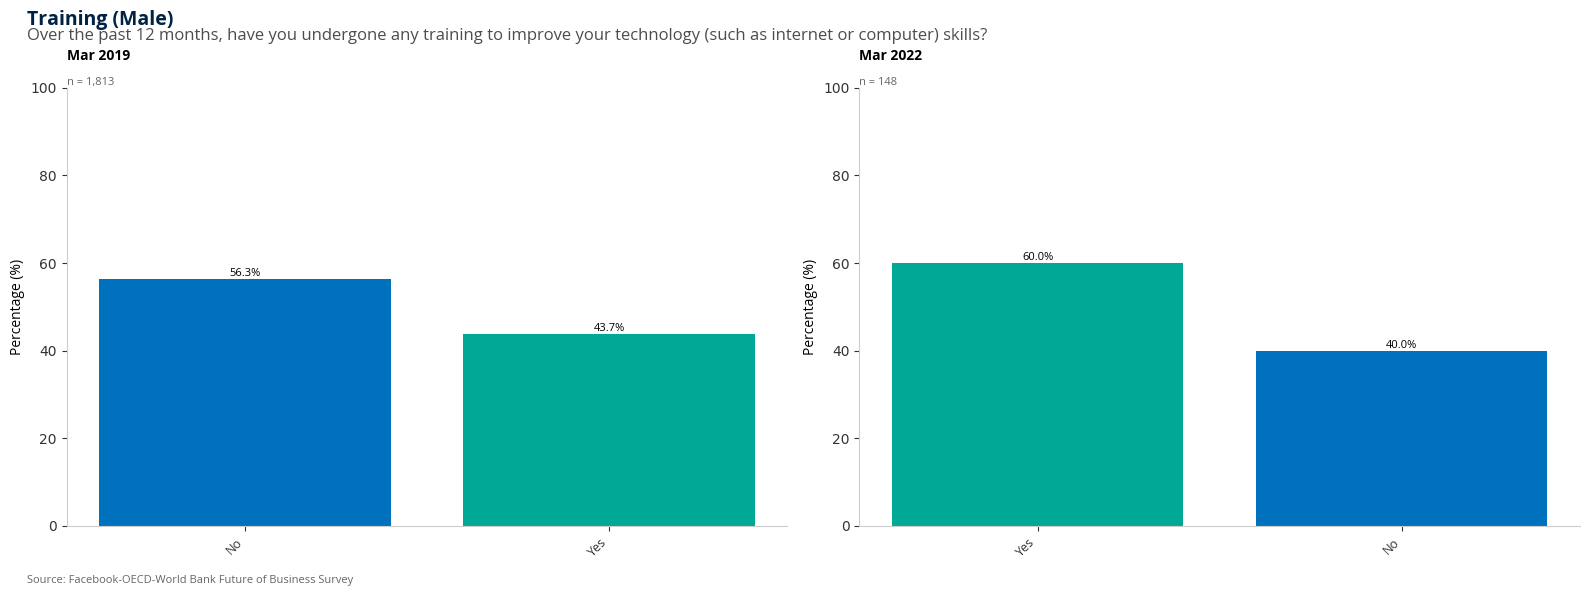

In [817]:
questions_in_all_4 = questions[questions['question_group'] == 57]['question'].iloc[0]

# Filter all dataframes
training = filter_fobs_by_questions(questions_in_all_4, fob_gender_male_dfs)


# Create grid with 2 rows
plot_surveys_grid(training, rows=1, figsize_per_plot=(8,6), 
                  main_title='Training (Male)',
                  subtitle=questions[questions['question_group'] == 57]['question'].iloc[0][0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

### Digital Adoption

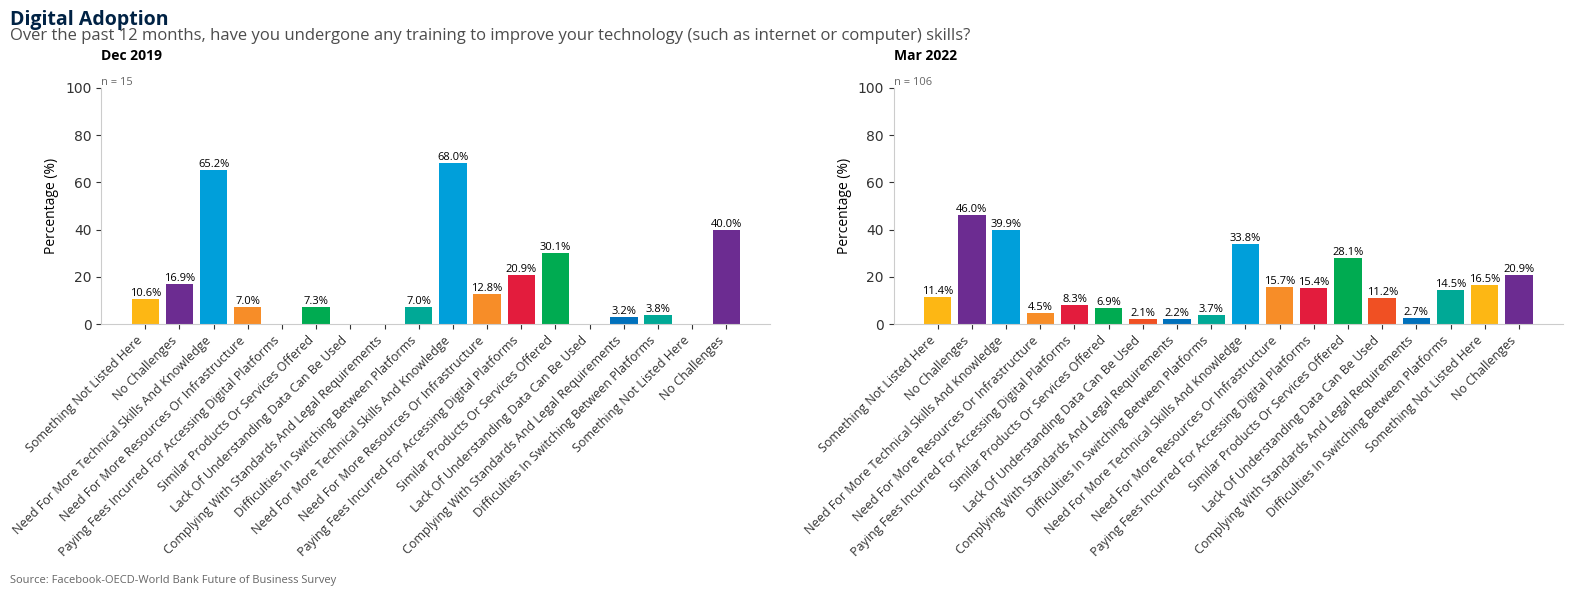

In [ ]:
questions_digital = questions[questions['question_group'] == 2]['question'].iloc[0]

# Filter all dataframes
digital = {}

fob22_digital = fob22[fob22['question'].str.contains('digital platforms for')].copy()
yes_mask = fob22_digital['response'] == 'Yes'
fob22_digital.loc[yes_mask, 'response'] = fob22_digital.loc[yes_mask, 'question'].apply(
    lambda x: x.split(' - ', 1)[1].strip() if ' - ' in x
    else (x.split('-', 1)[1].strip() if '-' in x else 'Yes')
)
fob22_digital = fob22_digital[fob22_digital['response'] != 'No']
fob22_digital = fob22_digital[fob22_digital['n'] > 0]

digital['fob22'] = fob22_digital

fob22_digital_female = fob_gender_female_dfs['fob22'].copy()
fob22_digital_female = fob22_digital_female[fob22_digital_female['question'].str.contains('digital platforms for')]
yes_mask = fob22_digital_female['response'] == 'Yes'
fob22_digital_female.loc[yes_mask, 'response'] = fob22_digital_female.loc[yes_mask, 'question'].apply(
    lambda x: x.split(' - ', 1)[1].strip() if ' - ' in x
    else (x.split('-', 1)[1].strip() if '-' in x else 'Yes')
)
fob22_digital_female = fob22_digital_female[fob22_digital_female['response'] != 'No']
fob22_digital_female = fob22_digital_female[fob22_digital_female['n'] > 0]

digital['fob22_female'] = fob22_digital_female
digital['fob22'] = fob22_digital

# Create grid with 2 rows
plot_surveys_grid(digital, rows=1, figsize_per_plot=(8,6), 
                  main_title='Digital Adoption',
                  subtitle=questions_in_all_4[0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

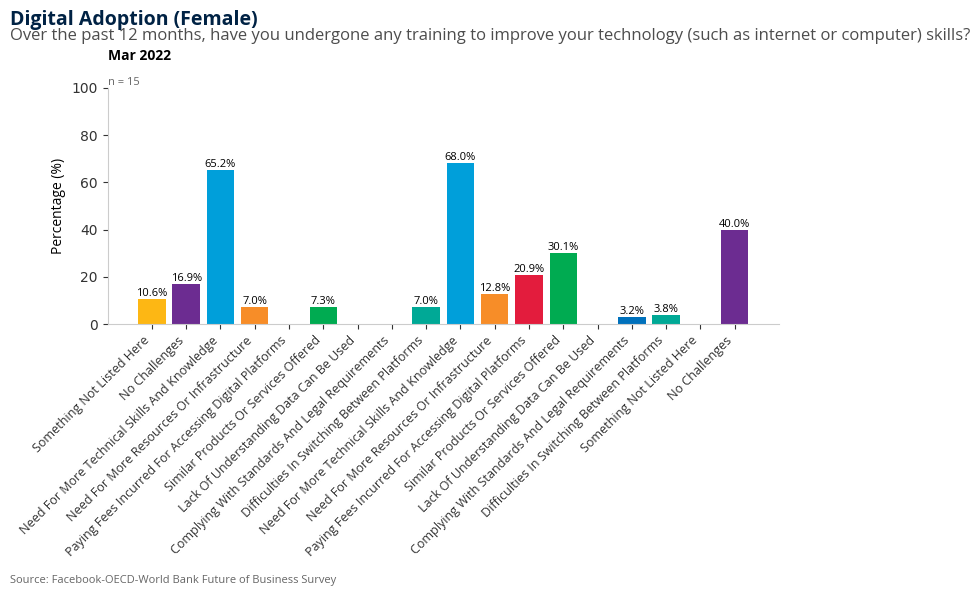

In [853]:
questions_digital = questions[questions['question_group'] == 2]['question'].iloc[0]

# Filter all dataframes
digital = {}

fob22_digital_female = fob_gender_female_dfs['fob22'].copy()
fob22_digital_female = fob22_digital_female[fob22_digital_female['question'].str.contains('digital platforms for')]
yes_mask = fob22_digital_female['response'] == 'Yes'
fob22_digital_female.loc[yes_mask, 'response'] = fob22_digital_female.loc[yes_mask, 'question'].apply(
    lambda x: x.split(' - ', 1)[1].strip() if ' - ' in x
    else (x.split('-', 1)[1].strip() if '-' in x else 'Yes')
)
fob22_digital_female = fob22_digital_female[fob22_digital_female['response'] != 'No']
fob22_digital_female = fob22_digital_female[fob22_digital_female['n'] > 0]

digital['fob22'] = fob22_digital_female
# Create grid with 2 rows
plot_surveys_grid(digital, rows=1, figsize_per_plot=(8,6), 
                  main_title='Digital Adoption (Female)',
                  subtitle=questions_in_all_4[0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

### International Trade

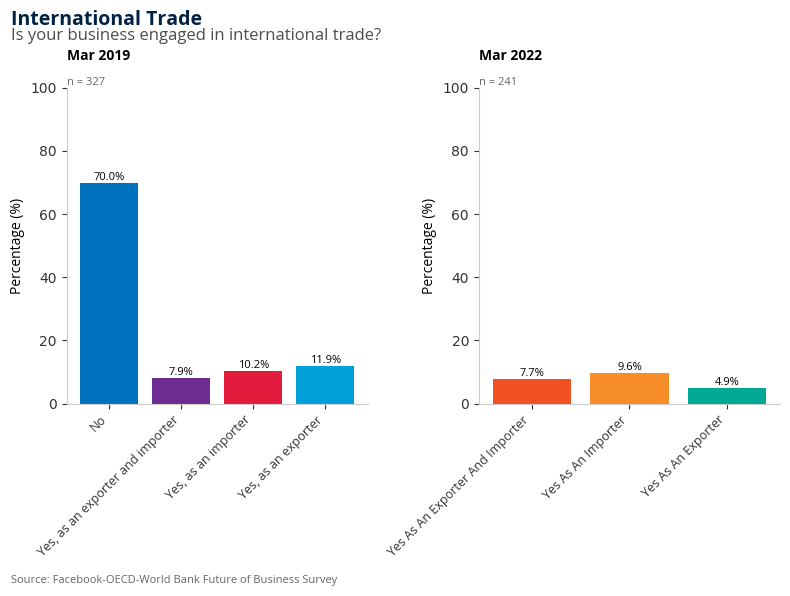

In [868]:
questions_in_all_4 = questions[questions['question_group'] == 87]['question'].iloc[0]

# Filter all dataframes
sectors = filter_fobs_by_questions(questions_in_all_4, fob_dfs)


# Create grid with 2 rows
plot_surveys_grid(sectors, rows=1, figsize_per_plot=(4,6), 
                  main_title='International Trade',
                  subtitle=questions[questions['question_group'] == 87]['question'].iloc[0][0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

### Sectors of Employment

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_2791/3994907851.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fob19_sectors['response'].replace({'Services (including trade, restaurants, computer programming, media, education, legal services, etc.)': 'Services',
/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_2791/3994907851.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

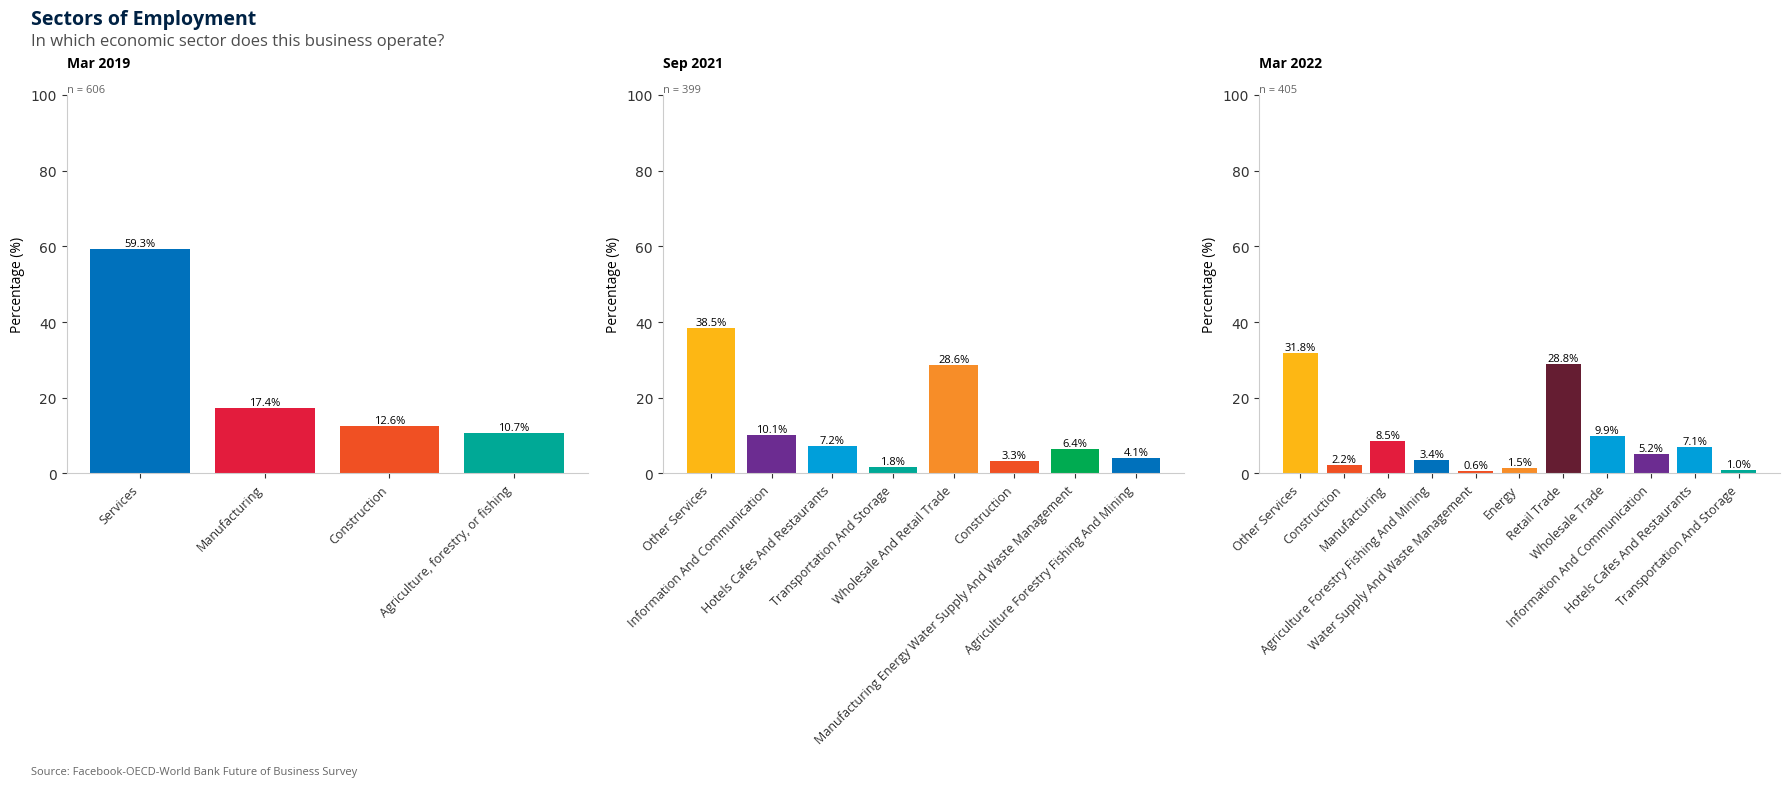

In [858]:
questions_in_all_4 = questions[questions['num_surveys'] == 3]['question'].iloc[0]

# Filter all dataframes
sectors = filter_fobs_by_questions(questions_in_all_4, fob_dfs)

fob19_sectors = sectors['fob19_spring']
fob19_sectors = fob19_sectors[~(fob19_sectors['question'].str.contains('sub-sectors'))]

fob21_sectors = sectors['fob21']
fob21_sectors = fob21_sectors[~(fob21_sectors['question'].str.contains('sub-sector'))]

fob22_sectors = sectors['fob22']
fob22_sectors = fob22_sectors[~(fob22_sectors['question'].str.contains('sub-sector'))]

fob19_sectors['response'].replace({'Services (including trade, restaurants, computer programming, media, education, legal services, etc.)': 'Services',
                                   'Construction (including plumbing, head and air-conditioning installation)': 'Construction'}
                                  , inplace=True)
sectors['fob19_spring'] = fob19_sectors
sectors['fob21'] = fob21_sectors
sectors['fob22'] = fob22_sectors


# Create grid with 2 rows
plot_surveys_grid(sectors, rows=1, figsize_per_plot=(6,8), 
                  main_title='Sectors of Employment',
                  subtitle=questions[questions['num_surveys'] == 3]['question'].iloc[0][0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_2791/206803539.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fob19_sectors['response'].replace({'Services (including trade, restaurants, computer programming, media, education, legal services, etc.)': 'Services',


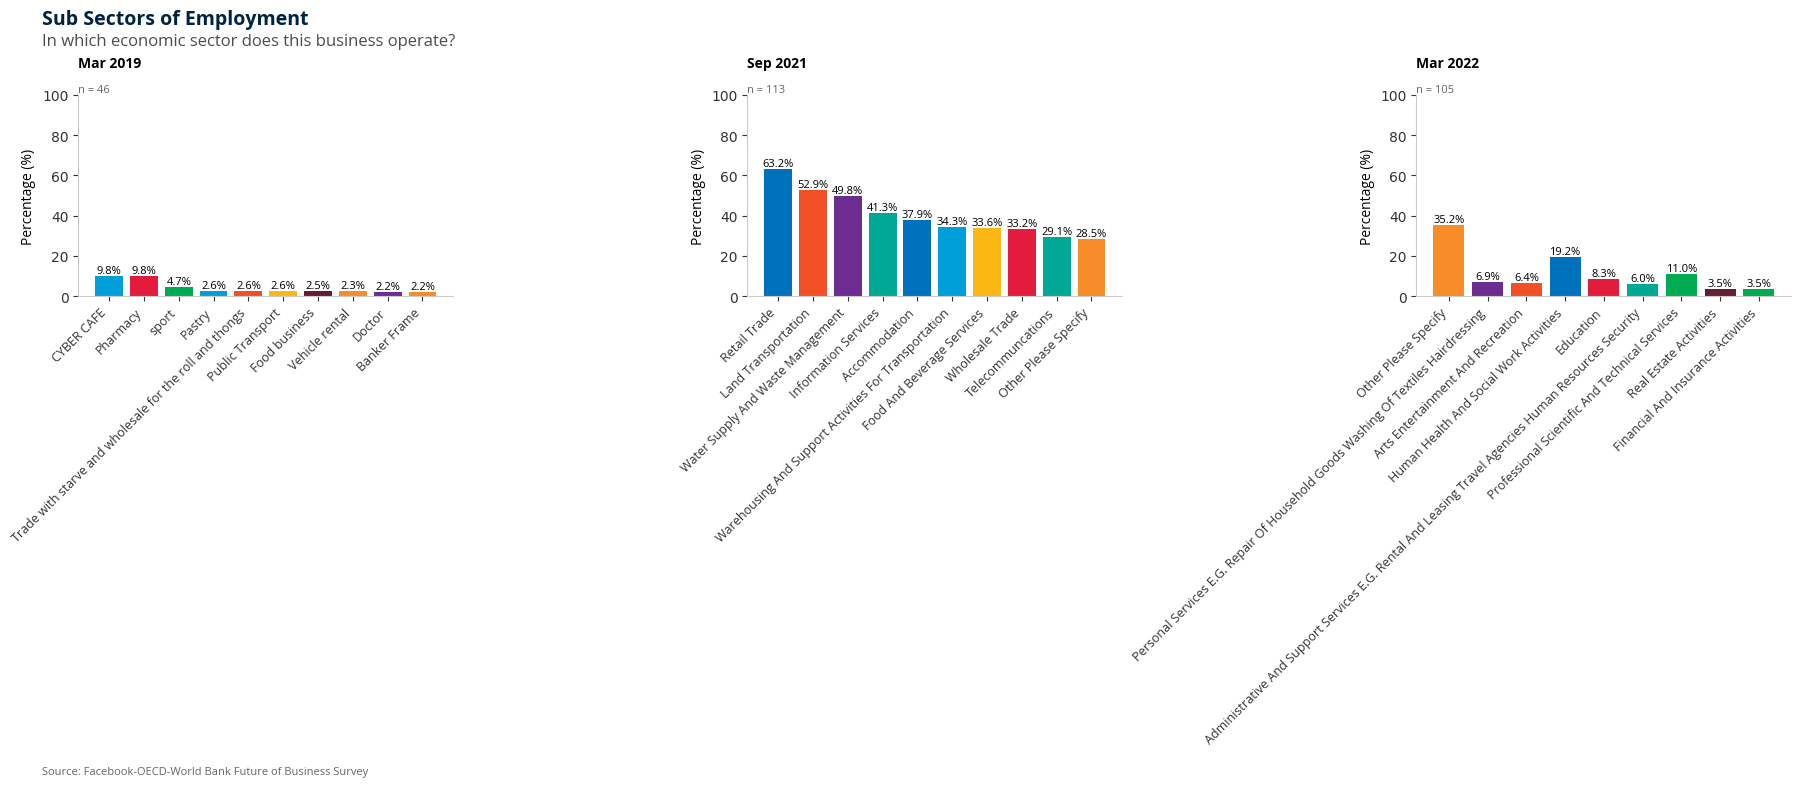

In [870]:
question_subsector = questions[questions['num_surveys'] == 3]['question'].iloc[0]

# Filter all dataframes
sectors = filter_fobs_by_questions(question_subsector, fob_dfs)

fob19_sectors = sectors['fob19_spring']
fob19_sectors = fob19_sectors[(fob19_sectors['question'].str.contains('sub-sectors'))]
fob19_sectors = fob19_sectors[fob19_sectors['variable'].str.contains('svc_translation')]
fob19_sectors = fob19_sectors.sort_values(by='value', ascending=False).head(10)

fob21_sectors = sectors['fob21']
fob21_sectors = fob21_sectors[(fob21_sectors['question'].str.contains('sub-sector'))]
fob21_sectors = fob21_sectors.sort_values(by='value', ascending=False).head(10)

fob22_sectors = sectors['fob22']
fob22_sectors = fob22_sectors[(fob22_sectors['question'].str.contains('sub-sector'))]

fob19_sectors['response'].replace({'Services (including trade, restaurants, computer programming, media, education, legal services, etc.)': 'Services',
                                   'Construction (including plumbing, head and air-conditioning installation)': 'Construction'}
                                  , inplace=True)
sectors['fob19_spring'] = fob19_sectors
sectors['fob21'] = fob21_sectors
sectors['fob22'] = fob22_sectors


# Create grid with 2 rows
plot_surveys_grid(sectors, rows=1, figsize_per_plot=(6,8), 
                  main_title='Sub Sectors of Employment',
                  subtitle=questions[questions['num_surveys'] == 3]['question'].iloc[0][0],
                  source='Facebook-OECD-World Bank Future of Business Survey')
plt.show();